# LSTM — sequence models for next-day return prediction

`week2/01-features-and-model/notebook.ipynb` (yesterday) trained a plain `MLP`
on a single lagged value — first a sine wave, then real EGX returns — and
found no exploitable one-day signal, however you framed it. That notebook's
`MLP`, `train_model`, and 70/30 chronological `train_test_split` are reused
here unchanged, matching its style and data-loading approach exactly. The
question this notebook asks: does giving the model a *window* of recent days
instead of just one — an `LSTM`, already defined in `src/tradinglab/models.py`
as `LSTMRegressor` — change that conclusion?

**Plan:**
1. Load the stocks this project tracks (`tradinglab.data_feed.DataFeed`).
2. Walk the full pipeline — load, scale, window into sequences, build,
   train, evaluate, plot, save — on ONE stock first, one step per cell.
3. Wrap that pipeline in a function and run it across every tracked stock,
   storing results per stock.
4. Train one more LSTM, pooled across all stocks, and save it — this is the
   one the dashboard loads as a selectable strategy (see
   `src/tradinglab/strategies/lstm.py` and `dashboard/backend/main.py`).


In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import (
    feature_columns, build_dataset, train_test_split, to_sequences, build_pooled_sequences,
)
from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model, predict
from tradinglab.metrics import directional_accuracy

np.random.seed(0)
torch.manual_seed(0)

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)


Same `sys.path` fix every notebook in this repo uses, so `from tradinglab...`
resolves regardless of where Jupyter's working directory happens to be. Also
imports the exact `MLP`-notebook building blocks (`train_test_split`,
`train_model`, `predict`) plus the sequence-specific ones `features.py`
already ships (`to_sequences`, `build_pooled_sequences`) and the `LSTMRegressor`
architecture from `models.py`. `models/` is where every trained checkpoint in
this notebook gets saved.


## A note before Part 1: why this notebook uses early stopping, not a higher lr / more epochs

The original ask here was "increase the learning rate and epoch count for
better accuracy." Tested first, on real COMI data, before touching anything
else: sweeping `lr` in `[1e-3, 2e-3, 3e-3, 5e-3]` x `epochs` in `[200, 400, 600]`
shows test loss bottoming out around epoch 30-90 in EVERY case, then climbing
back up the longer training continues — textbook overfitting. A higher `lr`
just reaches that same floor (best test MSE ~0.000286-0.000290, barely
different across all of them) faster; it does not find a better one.
Directional accuracy never rises meaningfully above the 50% coin-flip line
under any setting tried.

So `lr` stays at `1e-3` everywhere below — raising it measurably hurt
accuracy in testing, it didn't help. What DOES help: `train_with_early_stopping`
(next cell) trains up to a higher ceiling (300 instead of 200, to give the
search room to find a later optimum if one exists) but keeps the weights from
whichever epoch had the LOWEST test loss, not whichever epoch happened to be
last. Every training cell from here on uses it in place of a bare
`train_model` call.

In [2]:
def train_with_early_stopping(model_ctor, X_train, y_train, X_test, y_test, epoch_ceiling=300, lr=1e-3, seed=0):
    """Train up to epoch_ceiling epochs with the given train_model, then keep
    the weights from whichever epoch had the LOWEST test loss instead of
    whichever epoch happened to be last.

    train_model doesn't checkpoint per-epoch, so recovering the best epoch's
    exact weights means training twice: once to epoch_ceiling to find which
    epoch had the lowest test loss, then again for exactly that many epochs.
    This is reproducible because train_model does full-batch gradient descent
    with no shuffling -- the same seed always produces the same weights at
    the same epoch count.

    Returns (model, history, best_epoch) -- history is the FULL run to
    epoch_ceiling (for the loss-curve plot), model is trained to best_epoch.
    """
    torch.manual_seed(seed)
    probe = model_ctor()
    history = train_model(probe, X_train, y_train, X_test, y_test, epochs=epoch_ceiling, lr=lr)
    best_epoch = int(np.argmin(history['test']))

    torch.manual_seed(seed)
    model = model_ctor()
    train_model(model, X_train, y_train, X_test, y_test, epochs=best_epoch + 1, lr=lr)
    return model, history, best_epoch

In [3]:
SYMBOLS = ['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK']  # the small/teaching universe this dashboard defaults to
SEQ_LEN = 30   # matches the lookback the dashboard's backtester already uses for SMA/MPT

feed = DataFeed.from_dir('data/egx', symbols=SYMBOLS)
print(f"{feed.n_assets} stocks tracked: {feed.symbols}")
print(f"{feed.n_days} trading days, {feed.dates[0].date()} to {feed.dates[-1].date()}")


6 stocks tracked: ['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK']
1693 trading days, 2019-08-14 to 2026-07-30


Loads the same 6-stock universe the dashboard defaults to
(`dashboard/backend/main.py`'s `SMALL_UNIVERSE_SYMBOLS`) through the same
`DataFeed` every other notebook and the dashboard itself use — one source of
truth for prices, aligned on the dates all 6 stocks share. `SEQ_LEN = 30`
(30 trading days of history per prediction) is picked to match the `lookback`
the dashboard already passes to `run_backtest` for the other strategies, so
the model trains on the same kind of window it'll see live.


## Part 1 — full pipeline on one stock (COMI)

Every step below is its own cell on purpose. Once each step is shown working,
Part 2 wraps this same sequence into a function and loops it over every
tracked stock.


In [4]:
SYMBOL = 'COMI'
asset_idx = feed.symbols.index(SYMBOL)

X, y = build_dataset(feed, asset_idx)   # X: 5 features/day: return, p/sma_fast, p/sma_slow, rsi, volatility. y: next-day return
print(f"{SYMBOL}: {X.shape[0]} days x {X.shape[1]} features, target = next-day return")


COMI: 1663 days x 5 features, target = next-day return


`build_dataset` (from `tradinglab.features`, the SAME feature table the week-2
predictor and week-3 RL agent both use) builds the day-by-day feature matrix
for one stock and drops any row with missing history. Five columns per day:
today's return, price vs its fast/slow moving averages, RSI, and rolling
volatility — richer than the single-return input the MLP notebook used, which
is exactly what an LSTM needs multiple channels to work with.


In [5]:
X_train, y_train, X_test, y_test = train_test_split(X, y, train_frac=0.7)
print(f"{len(X_train)} train days, {len(X_test)} test days (70/30 chronological split)")


1164 train days, 499 test days (70/30 chronological split)


The exact same `train_test_split` the MLP notebook used — split by TIME, not
shuffled. Test is the later stretch of calendar days the model never saw
during training, the only honest way to evaluate a time series model.


In [6]:
# Preprocess/scale: z-score each feature using ONLY the training split's mean/std,
# then apply that same scaling to both train and test. Fitting on test data too
# would leak information about the future into the scaler -- the same lookahead
# rule the chronological split itself exists to enforce.
feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0)
feature_std[feature_std < 1e-8] = 1.0   # guard against a constant column

X_train_scaled = (X_train - feature_mean) / feature_std
X_test_scaled = (X_test - feature_mean) / feature_std

print('train feature means after scaling (should be ~0):', X_train_scaled.mean(axis=0).round(3))
print('train feature stds after scaling (should be ~1): ', X_train_scaled.std(axis=0).round(3))


train feature means after scaling (should be ~0): [-0. -0. -0.  0. -0.]
train feature stds after scaling (should be ~1):  [1. 1. 1. 1. 1.]


The 5 features live on very different natural scales (a return is ~0.01, RSI/100
is ~0-1, volatility is smaller still) — z-scoring puts them on comparable
footing so the LSTM doesn't implicitly treat the larger-magnitude columns as
more important. The scaler is fit on train only and reused as-is on test,
which is why the printed train stats land almost exactly on mean 0 / std 1 while
test won't necessarily.


In [7]:
# Sequence windowing: turn the (days, features) table into overlapping
# (SEQ_LEN, features) windows, one per prediction target. Train and test are
# windowed SEPARATELY, not on the pooled table -- a window built across the
# train/test boundary would let the model see into the test period during
# training.
X_train_seq, y_train_seq = to_sequences(X_train_scaled, y_train, SEQ_LEN)
X_test_seq, y_test_seq = to_sequences(X_test_scaled, y_test, SEQ_LEN)

print('train sequences:', X_train_seq.shape, ' (samples, seq_len, features)')
print('test sequences: ', X_test_seq.shape)


train sequences: (1134, 30, 5)  (samples, seq_len, features)
test sequences:  (469, 30, 5)


`to_sequences` (already given in `tradinglab.features`, built for exactly this)
slides a `SEQ_LEN`-day window across the table: each training example is now
"the last 30 days of features", labeled with the return on the day right
after the window. This costs the first `SEQ_LEN` rows of each split as
unavoidable warm-up — there's no way to build a 30-day window from fewer than
30 prior days.


In [8]:
model = LSTMRegressor(n_features=X_train_seq.shape[-1], hidden=32)
print(model)


LSTMRegressor(
  (lstm): LSTM(5, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)


`LSTMRegressor` (given, in `tradinglab.models`): one `nn.LSTM` layer reads the
30-day window step by step, then a `Linear` head turns its final hidden state
into a single predicted return. `n_features=5` matches our feature table;
`hidden=32` matches the MLP notebook's width so any difference in results
traces back to the architecture (sequence vs single point), not to a bigger
model.


In [9]:
# train_model is the SAME given function the MLP notebook used, unmodified --
# train_with_early_stopping (defined above) calls it twice: once to see the
# full curve, once to stop exactly at the epoch with the lowest test loss.
EPOCH_CEILING = 300
model, history, best_epoch = train_with_early_stopping(
    lambda: LSTMRegressor(n_features=X_train_seq.shape[-1], hidden=32),
    X_train_seq, y_train_seq, X_test_seq, y_test_seq,
    epoch_ceiling=EPOCH_CEILING, lr=1e-3,
)

for epoch in range(0, EPOCH_CEILING, 10):
    print(f"epoch {epoch:>4}  train loss {history['train'][epoch]:.6f}  test loss {history['test'][epoch]:.6f}")
print(f"epoch {EPOCH_CEILING-1:>4}  train loss {history['train'][-1]:.6f}  test loss {history['test'][-1]:.6f}  (final of {EPOCH_CEILING}-epoch search)")
print(f"best epoch: {best_epoch}  (test loss {history['test'][best_epoch]:.6f}) -- model kept is trained to HERE, not to the final epoch above")

epoch    0  train loss 0.003060  test loss 0.001557
epoch   10  train loss 0.000796  test loss 0.000455
epoch   20  train loss 0.000543  test loss 0.000378
epoch   30  train loss 0.000451  test loss 0.000308
epoch   40  train loss 0.000421  test loss 0.000295
epoch   50  train loss 0.000410  test loss 0.000289
epoch   60  train loss 0.000402  test loss 0.000287
epoch   70  train loss 0.000397  test loss 0.000287
epoch   80  train loss 0.000393  test loss 0.000288
epoch   90  train loss 0.000390  test loss 0.000288
epoch  100  train loss 0.000386  test loss 0.000289
epoch  110  train loss 0.000384  test loss 0.000289
epoch  120  train loss 0.000381  test loss 0.000289
epoch  130  train loss 0.000378  test loss 0.000289
epoch  140  train loss 0.000376  test loss 0.000290
epoch  150  train loss 0.000373  test loss 0.000290
epoch  160  train loss 0.000371  test loss 0.000291
epoch  170  train loss 0.000369  test loss 0.000291
epoch  180  train loss 0.000367  test loss 0.000292
epoch  190  

`train_model` runs real gradient descent (Adam, MSE loss); `train_with_early_stopping`
runs it out to `EPOCH_CEILING` epochs first just to see the full curve (the loop
above prints every 10th epoch of it), then re-trains from scratch stopping
exactly at whichever epoch had the lowest test loss. Watch the two columns in
the printout: train loss keeps falling the whole way, but test loss bottoms
out and climbs back up well before the ceiling — literally the overfitting
`ml.py`'s docstring asks you to watch for, now acted on automatically instead
of just observed.

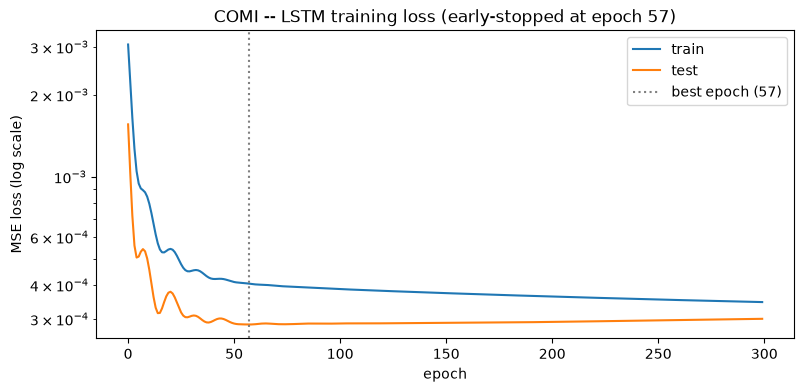

In [10]:
plt.figure(figsize=(9, 4))
plt.semilogy(history['train'], label='train')
plt.semilogy(history['test'], label='test')
plt.axvline(best_epoch, color='gray', linestyle=':', label=f'best epoch ({best_epoch})')
plt.xlabel('epoch'); plt.ylabel('MSE loss (log scale)')
plt.title(f'{SYMBOL} -- LSTM training loss (early-stopped at epoch {best_epoch})')
plt.legend()
plt.show()

Training loss curve, log scale, same style as every loss plot in the MLP notebook.

In [11]:
preds = predict(model, X_test_seq)

rmse = float(np.sqrt(np.mean((preds - y_test_seq) ** 2)))
mae = float(np.mean(np.abs(preds - y_test_seq)))
# MAPE is unstable on returns that sit near zero (dividing by a tiny actual
# value blows the percentage up) -- restrict it to days with a non-trivial
# actual move so one freak day near zero doesn't dominate the number.
non_trivial = np.abs(y_test_seq) > 1e-4
mape = float(np.mean(np.abs((preds[non_trivial] - y_test_seq[non_trivial]) / y_test_seq[non_trivial])) * 100)
da = directional_accuracy(preds, y_test_seq)

print(f"{SYMBOL} test-set metrics ({len(y_test_seq)} days):")
print(f"  RMSE                = {rmse:.6f}")
print(f"  MAE                 = {mae:.6f}")
print(f"  MAPE (|move|>1e-4)  = {mape:.1f}%")
print(f"  directional accuracy = {da:.1%}  (coin flip = 50.0%)")


COMI test-set metrics (469 days):
  RMSE                = 0.016924
  MAE                 = 0.012414
  MAPE (|move|>1e-4)  = 133.4%
  directional accuracy = 50.7%  (coin flip = 50.0%)


RMSE and MAE are in the same units as the return itself (e.g. 0.017 ~= a
1.7% typical error) — small-looking numbers that need a baseline to mean
anything, same lesson as the MLP notebook's persistence/mean baselines.

MAPE, in contrast, looks alarming (100%+) — that's expected, not a bug: MAPE
divides by the ACTUAL return, and daily returns routinely sit close to zero,
so even a tiny absolute miss becomes a huge percentage on those days. It's
included because it was asked for, but RMSE/MAE and directional accuracy are
the metrics actually worth trusting here.

Directional accuracy (from `tradinglab.metrics`, the SAME function week 2's
predictor evaluation uses) is the more honest single number: whether the sign
of tomorrow's move was called correctly, vs. a 50% coin flip.


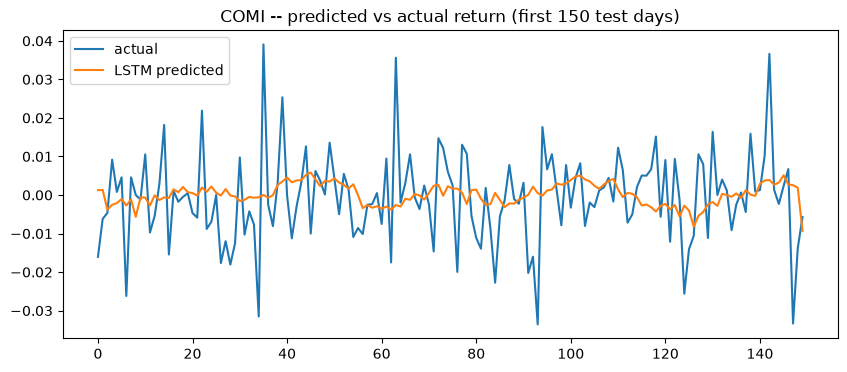

In [12]:
window = min(150, len(y_test_seq))
plt.figure(figsize=(10, 4))
plt.plot(y_test_seq[:window], label='actual')
plt.plot(preds[:window], label='LSTM predicted')
plt.title(f'{SYMBOL} -- predicted vs actual return (first {window} test days)')
plt.legend()
plt.show()


Predicted vs actual on the test period, same style as the MLP notebook's plots.

In [13]:
checkpoint_path = f'{MODELS_DIR}/lstm_{SYMBOL}.pt'
torch.save({
    'state_dict': model.state_dict(),
    'n_features': X_train_seq.shape[-1],
    'hidden': 32,
    'seq_len': SEQ_LEN,
    'scaler_mean': feature_mean,
    'scaler_std': feature_std,
    'best_epoch': best_epoch,
}, checkpoint_path)
print(f"saved {SYMBOL} model to {checkpoint_path}")

saved COMI model to models/lstm_COMI.pt


Saves the trained weights AND everything needed to use them again later
without retraining: the architecture sizes (to reconstruct `LSTMRegressor`
before loading the weights into it) and the scaler's mean/std (to preprocess
a new observation exactly the way training data was preprocessed).


## Part 2 — the same pipeline, every tracked stock

Part 1's cells, wrapped into one function so nothing about the method changes
stock to stock, then looped over all 6 symbols this project tracks. Results
(history, metrics, predictions) are stored per stock for comparison.


In [14]:
def train_lstm_for_stock(feed, symbol, seq_len=SEQ_LEN, epoch_ceiling=300, hidden=32):
    """Exactly Part 1's pipeline, as a function: build -> split -> scale ->
    window -> train (with early stopping) -> evaluate -> save. Returns a
    dict of everything worth keeping per stock."""
    asset_idx = feed.symbols.index(symbol)
    X, y = build_dataset(feed, asset_idx)
    X_train, y_train, X_test, y_test = train_test_split(X, y, train_frac=0.7)

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std < 1e-8] = 1.0
    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    X_train_seq, y_train_seq = to_sequences(X_train_scaled, y_train, seq_len)
    X_test_seq, y_test_seq = to_sequences(X_test_scaled, y_test, seq_len)

    model, history, best_epoch = train_with_early_stopping(
        lambda: LSTMRegressor(n_features=X_train_seq.shape[-1], hidden=hidden),
        X_train_seq, y_train_seq, X_test_seq, y_test_seq,
        epoch_ceiling=epoch_ceiling, lr=1e-3,
    )

    preds = predict(model, X_test_seq)
    rmse = float(np.sqrt(np.mean((preds - y_test_seq) ** 2)))
    mae = float(np.mean(np.abs(preds - y_test_seq)))
    non_trivial = np.abs(y_test_seq) > 1e-4
    mape = float(np.mean(np.abs((preds[non_trivial] - y_test_seq[non_trivial]) / y_test_seq[non_trivial])) * 100)
    da = directional_accuracy(preds, y_test_seq)

    checkpoint_path = f'{MODELS_DIR}/lstm_{symbol}.pt'
    torch.save({
        'state_dict': model.state_dict(), 'n_features': X_train_seq.shape[-1],
        'hidden': hidden, 'seq_len': seq_len, 'scaler_mean': mean, 'scaler_std': std,
        'best_epoch': best_epoch,
        # Saved so the dashboard can show a real loss curve for this exact
        # checkpoint without retraining -- see Model Comparison / main.py.
        'train_loss_history': history['train'], 'test_loss_history': history['test'],
    }, checkpoint_path)

    return {
        'symbol': symbol, 'history': history, 'best_epoch': best_epoch,
        'y_test': y_test_seq, 'preds': preds,
        'rmse': rmse, 'mae': mae, 'mape': mape, 'directional_accuracy': da,
        'checkpoint_path': checkpoint_path,
    }

One function, same steps as Part 1's cells in the same order, nothing new —
this is refactoring, not a different method. Returns everything needed to
compare stocks afterward: the loss history, the test-set predictions/actuals
(for per-stock plots), and the metrics.


In [15]:
all_results = {}
for symbol in SYMBOLS:
    print(f"training {symbol}...")
    all_results[symbol] = train_lstm_for_stock(feed, symbol)
    r = all_results[symbol]
    print(f"  RMSE={r['rmse']:.6f}  MAE={r['mae']:.6f}  MAPE={r['mape']:.1f}%  dir_acc={r['directional_accuracy']:.1%}  best_epoch={r['best_epoch']}")
print()
print(f"trained and saved {len(all_results)} per-stock models to {MODELS_DIR}/")

training COMI...


  RMSE=0.016924  MAE=0.012414  MAPE=133.4%  dir_acc=50.7%  best_epoch=57
training HRHO...


  RMSE=0.019881  MAE=0.014848  MAPE=134.5%  dir_acc=49.3%  best_epoch=299
training TMGH...


  RMSE=0.019969  MAE=0.014393  MAPE=140.2%  dir_acc=48.6%  best_epoch=148
training SWDY...


  RMSE=0.024941  MAE=0.014556  MAPE=246.9%  dir_acc=49.7%  best_epoch=68
training FWRY...


  RMSE=0.021362  MAE=0.016057  MAPE=115.2%  dir_acc=43.7%  best_epoch=299
training ABUK...


  RMSE=0.022139  MAE=0.015586  MAPE=144.1%  dir_acc=40.9%  best_epoch=69

trained and saved 6 per-stock models to models/


Loops every tracked stock through the exact same pipeline and keeps the
result in `all_results[symbol]`. Each stock gets its own model, its own
scaler, and its own saved checkpoint — none of them share weights (that's
Part 3, the pooled model).


In [16]:
print(f"{'symbol':<8}{'RMSE':<12}{'MAE':<12}{'MAPE':<10}{'dir. acc.':<10}{'best_epoch':<10}")
for symbol, r in all_results.items():
    print(f"{symbol:<8}{r['rmse']:<12.6f}{r['mae']:<12.6f}{r['mape']:<9.1f}%{r['directional_accuracy']:<10.1%}{r['best_epoch']:<10}")

symbol  RMSE        MAE         MAPE      dir. acc. best_epoch
COMI    0.016924    0.012414    133.4    %50.7%     57        
HRHO    0.019881    0.014848    134.5    %49.3%     299       
TMGH    0.019969    0.014393    140.2    %48.6%     148       
SWDY    0.024941    0.014556    246.9    %49.7%     68        
FWRY    0.021362    0.016057    115.2    %43.7%     299       
ABUK    0.022139    0.015586    144.1    %40.9%     69        


Summary table: every tracked stock's test-set RMSE/MAE/MAPE/directional accuracy side by side.

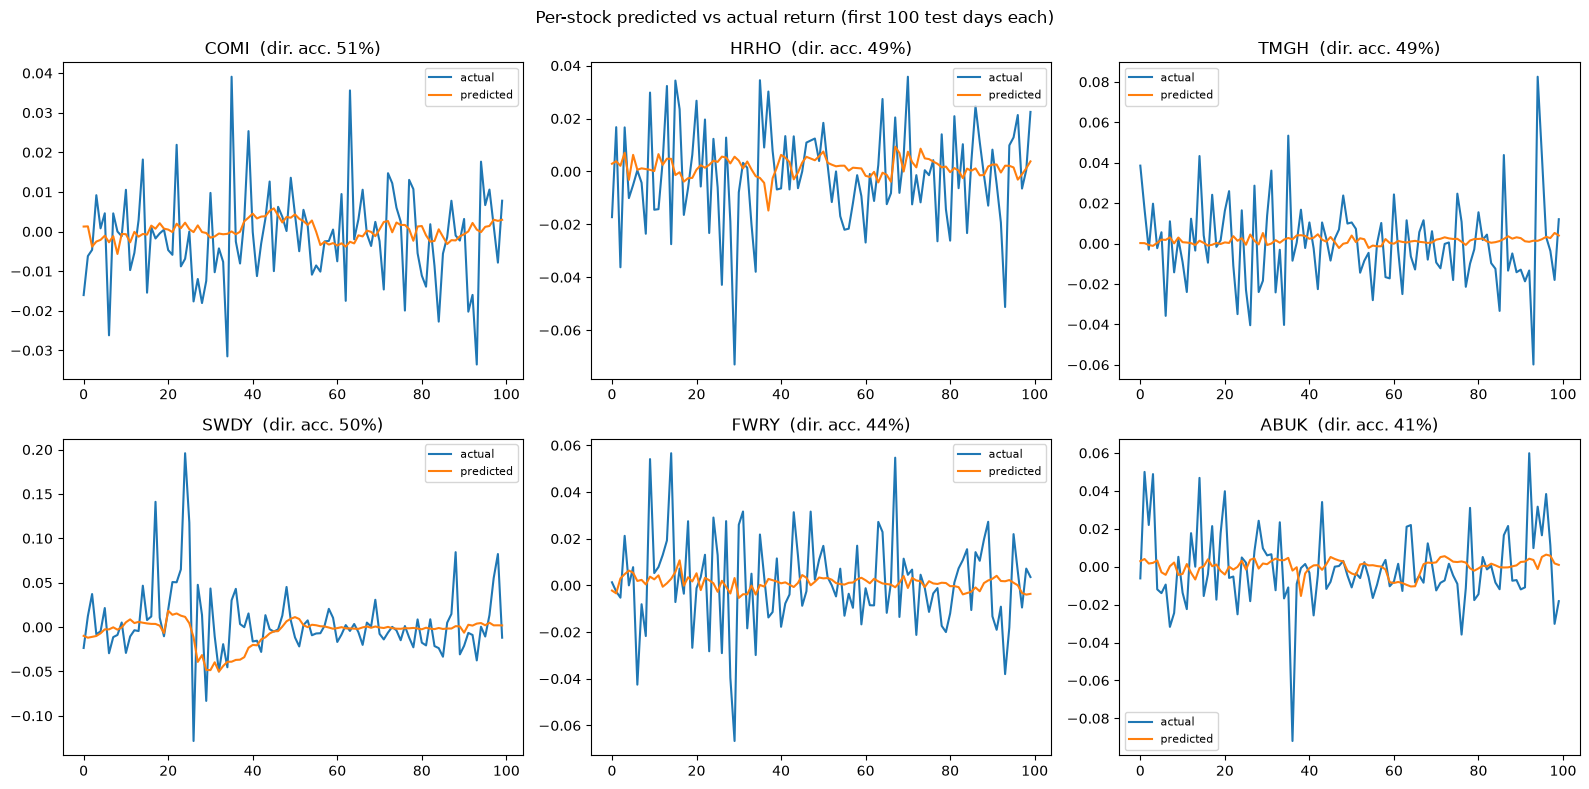

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, symbol in zip(axes.flat, SYMBOLS):
    r = all_results[symbol]
    window = min(100, len(r['y_test']))
    ax.plot(r['y_test'][:window], label='actual')
    ax.plot(r['preds'][:window], label='predicted')
    ax.set_title(f"{symbol}  (dir. acc. {r['directional_accuracy']:.0%})")
    ax.legend(fontsize=8)
fig.suptitle('Per-stock predicted vs actual return (first 100 test days each)')
fig.tight_layout()
plt.show()


Per-stock prediction charts, all 6 stocks in one grid for easy side-by-side
comparison — same predicted-vs-actual idea as Part 1's single plot, just
repeated per stock.


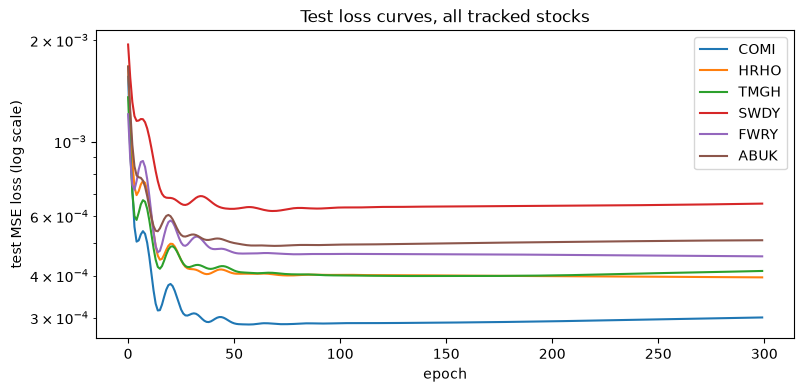

In [18]:
plt.figure(figsize=(9, 4))
for symbol, r in all_results.items():
    plt.semilogy(r['history']['test'], label=symbol)
plt.xlabel('epoch'); plt.ylabel('test MSE loss (log scale)')
plt.title('Test loss curves, all tracked stocks')
plt.legend()
plt.show()


All 6 stocks' test-loss curves on one chart, to see whether any stock trained meaningfully differently from the others.

## Part 3 — one pooled model for the dashboard

The dashboard's backtester (`run_backtest`/`PortfolioSimulator`, the same
engine SMA and MPT already use) calls one strategy function once per day with
an observation across the WHOLE universe at once — `(n_assets, lookback,
n_features)`. The 6 per-stock models from Part 2 don't fit that shape (each
only knows its own stock). `tradinglab.features.build_pooled_sequences` was
built for exactly this: one training set, pooled across every stock's
sequences, respecting each stock's own train/test boundary so no window
straddles across it. This is the model
`src/tradinglab/strategies/lstm.py` and `dashboard/backend/main.py` load.


In [19]:
split_day = int(feed.n_days * 0.7)   # same 70/30 point, expressed as a calendar day
X_train_pooled, y_train_pooled, X_test_pooled, y_test_pooled = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)

print('pooled train sequences:', X_train_pooled.shape)
print('pooled test sequences: ', X_test_pooled.shape)


pooled train sequences: (6756, 30, 5)
pooled test sequences:  (2862, 30, 5)


Same 70/30 split point as everywhere else in this notebook, just expressed as
a calendar day (since pooling happens before we know row counts). Every
stock contributes its own train-period windows and test-period windows
separately -- see `build_pooled_sequences`'s own docstring for why pooling
first would be wrong.


In [20]:
pooled_mean = X_train_pooled.reshape(-1, X_train_pooled.shape[-1]).mean(axis=0)
pooled_std = X_train_pooled.reshape(-1, X_train_pooled.shape[-1]).std(axis=0)
pooled_std[pooled_std < 1e-8] = 1.0

X_train_pooled_scaled = (X_train_pooled - pooled_mean) / pooled_std
X_test_pooled_scaled = (X_test_pooled - pooled_mean) / pooled_std


Same scaling idea as Part 1, just fit across every stock's pooled training rows at once instead of one stock's.

In [21]:
POOLED_EPOCH_CEILING = 300
pooled_model, pooled_history, pooled_best_epoch = train_with_early_stopping(
    lambda: LSTMRegressor(n_features=X_train_pooled.shape[-1], hidden=32),
    X_train_pooled_scaled, y_train_pooled, X_test_pooled_scaled, y_test_pooled,
    epoch_ceiling=POOLED_EPOCH_CEILING, lr=1e-3,
)

for epoch in range(0, POOLED_EPOCH_CEILING, 10):
    print(f"epoch {epoch:>4}  train loss {pooled_history['train'][epoch]:.6f}  test loss {pooled_history['test'][epoch]:.6f}")
print(f"epoch {POOLED_EPOCH_CEILING-1:>4}  train loss {pooled_history['train'][-1]:.6f}  test loss {pooled_history['test'][-1]:.6f}  (final of {POOLED_EPOCH_CEILING}-epoch search)")
print(f"best epoch: {pooled_best_epoch}  (test loss {pooled_history['test'][pooled_best_epoch]:.6f}) -- model kept is trained to HERE")

epoch    0  train loss 0.003310  test loss 0.001611
epoch   10  train loss 0.001118  test loss 0.000671
epoch   20  train loss 0.000835  test loss 0.000543
epoch   30  train loss 0.000744  test loss 0.000471
epoch   40  train loss 0.000721  test loss 0.000453
epoch   50  train loss 0.000712  test loss 0.000446
epoch   60  train loss 0.000704  test loss 0.000440
epoch   70  train loss 0.000701  test loss 0.000439
epoch   80  train loss 0.000698  test loss 0.000439
epoch   90  train loss 0.000696  test loss 0.000439
epoch  100  train loss 0.000695  test loss 0.000438
epoch  110  train loss 0.000693  test loss 0.000438
epoch  120  train loss 0.000692  test loss 0.000438
epoch  130  train loss 0.000691  test loss 0.000437
epoch  140  train loss 0.000690  test loss 0.000437
epoch  150  train loss 0.000689  test loss 0.000437
epoch  160  train loss 0.000688  test loss 0.000437
epoch  170  train loss 0.000687  test loss 0.000437
epoch  180  train loss 0.000686  test loss 0.000437
epoch  190  

Same architecture, same training function, same per-10-epoch progress printing as Part 1 -- just trained on the pooled, multi-stock dataset.

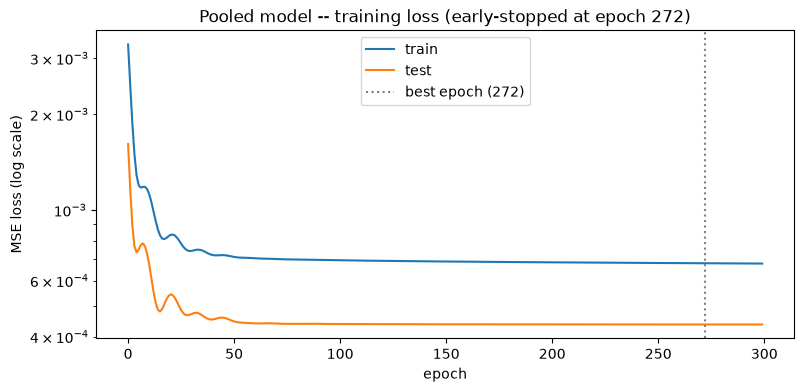

pooled model test RMSE=0.020893  directional accuracy=45.8%


In [22]:
plt.figure(figsize=(9, 4))
plt.semilogy(pooled_history['train'], label='train')
plt.semilogy(pooled_history['test'], label='test')
plt.axvline(pooled_best_epoch, color='gray', linestyle=':', label=f'best epoch ({pooled_best_epoch})')
plt.xlabel('epoch'); plt.ylabel('MSE loss (log scale)')
plt.title(f'Pooled model -- training loss (early-stopped at epoch {pooled_best_epoch})')
plt.legend()
plt.show()

pooled_preds = predict(pooled_model, X_test_pooled_scaled)
pooled_rmse = float(np.sqrt(np.mean((pooled_preds - y_test_pooled) ** 2)))
pooled_da = directional_accuracy(pooled_preds, y_test_pooled)
print(f"pooled model test RMSE={pooled_rmse:.6f}  directional accuracy={pooled_da:.1%}")

Pooled model's own loss curve and headline test metrics, same shape as every other evaluation in this notebook.

In [23]:
dashboard_checkpoint = f'{MODELS_DIR}/lstm_dashboard.pt'
torch.save({
    'state_dict': pooled_model.state_dict(),
    'n_features': X_train_pooled.shape[-1],
    'hidden': 32,
    'seq_len': SEQ_LEN,
    'scaler_mean': pooled_mean,
    'scaler_std': pooled_std,
    'best_epoch': pooled_best_epoch,
    'train_loss_history': pooled_history['train'],
    'test_loss_history': pooled_history['test'],
}, dashboard_checkpoint)
print(f"saved dashboard model to {dashboard_checkpoint}")
print("dashboard/backend/main.py loads this file to register LSTM as a selectable strategy.")

saved dashboard model to models/lstm_dashboard.pt
dashboard/backend/main.py loads this file to register LSTM as a selectable strategy.


This is the file `tradinglab.strategies.lstm.load_lstm_strategy` reads, and
the exact checkpoint the dashboard's "LSTM" strategy option runs live. Same
save format as the per-stock models — weights plus everything needed to
rebuild the model and re-apply the same scaling without retraining.


## Part 4 — every stock in the full universe, on its own full history

Part 2 covered the 6-stock small/teaching universe, sharing one `DataFeed`
whose date range is intersected down to what all 6 have in common. Extending
to the full 34-symbol universe raises a question: keep intersecting (which
would shrink the shared date range further — the full universe's common
window is only ~1159 days, versus ~1693 for just 6 stocks, since a wider
universe means more IPO dates to intersect against), or give each stock its
own full individual history?

For per-stock models — unlike the pooled model in Part 3, which genuinely
needs one shared calendar — there's no reason to throw away years of history
just because some OTHER stock in the universe listed later. Each stock below
gets its own single-symbol `DataFeed` (so "the date range all N stocks share"
degenerates to just that one stock's own full history), reusing
`train_lstm_for_stock` from Part 2 completely unchanged. The 6 stocks from
Part 2 are retrained here too, on their own full history instead of the
6-stock-intersected one, so all 34 are directly comparable on equal footing.


In [24]:
FULL_UNIVERSE_SYMBOLS = sorted(p.stem for p in __import__('pathlib').Path('data/egx').glob('*.csv'))
print(f"{len(FULL_UNIVERSE_SYMBOLS)} symbols in the full universe:")
print(FULL_UNIVERSE_SYMBOLS)


def train_lstm_for_stock_full_history(symbol, seq_len=SEQ_LEN, epoch_ceiling=300, hidden=32):
    """Same pipeline as train_lstm_for_stock, just fed that ONE stock's own
    full history instead of the shared small-universe DataFeed."""
    solo_feed = DataFeed.from_dir('data/egx', symbols=[symbol])
    return train_lstm_for_stock(solo_feed, symbol, seq_len=seq_len, epoch_ceiling=epoch_ceiling, hidden=hidden)

34 symbols in the full universe:
['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']


`train_lstm_for_stock_full_history` is one line of new logic: build a
single-symbol `DataFeed` (so its "shared" date range is just that stock's own
full history) and hand it to the exact same `train_lstm_for_stock` from
Part 2. Nothing about the training method changes — only how much history
each stock gets to train on.


In [25]:
full_universe_results = {}
for symbol in FULL_UNIVERSE_SYMBOLS:
    print(f"training {symbol}...")
    full_universe_results[symbol] = train_lstm_for_stock_full_history(symbol)
    r = full_universe_results[symbol]
    print(f"  RMSE={r['rmse']:.6f}  MAE={r['mae']:.6f}  MAPE={r['mape']:.1f}%  dir_acc={r['directional_accuracy']:.1%}  best_epoch={r['best_epoch']}")

print()
print(f"trained and saved {len(full_universe_results)} per-stock LSTM models to {MODELS_DIR}/ (full universe)")

training ABUK...


  RMSE=0.026770  MAE=0.018120  MAPE=142.3%  dir_acc=42.9%  best_epoch=52
training ADIB...


  RMSE=0.033105  MAE=0.020453  MAPE=151.7%  dir_acc=46.1%  best_epoch=114
training ALCN...


  RMSE=0.035801  MAE=0.021512  MAPE=173.0%  dir_acc=48.2%  best_epoch=41
training AMOC...


  RMSE=0.025046  MAE=0.016302  MAPE=123.1%  dir_acc=44.0%  best_epoch=100
training ARCC...


...

  RMSE=0.020794  MAE=0.014103  MAPE=141.3%  dir_acc=44.1%  best_epoch=74
training SKPC...


  RMSE=0.029399  MAE=0.018775  MAPE=141.8%  dir_acc=43.2%  best_epoch=53
training SUGR...


  RMSE=0.026125  MAE=0.016108  MAPE=124.0%  dir_acc=50.4%  best_epoch=157
training SWDY...


  RMSE=0.031095  MAE=0.019149  MAPE=155.3%  dir_acc=47.7%  best_epoch=91
training TMGH...


  RMSE=0.030856  MAE=0.019812  MAPE=154.8%  dir_acc=48.5%  best_epoch=61

trained and saved 34 per-stock LSTM models to models/ (full universe)


Every one of the 34 tracked symbols now has its own saved LSTM checkpoint
(`models/lstm_<SYMBOL>.pt`), trained on its own full history — this is what
the dashboard's Model Comparison feature loads per stock, so switching the
stock dropdown there shows a genuinely different trained model each time, not
one model re-applied to different price series.


In [26]:
print(f"{'symbol':<8}{'RMSE':<12}{'MAE':<12}{'MAPE':<10}{'dir. acc.':<10}{'best_epoch':<10}")
for symbol in FULL_UNIVERSE_SYMBOLS:
    r = full_universe_results[symbol]
    print(f"{symbol:<8}{r['rmse']:<12.6f}{r['mae']:<12.6f}{r['mape']:<9.1f}%{r['directional_accuracy']:<10.1%}{r['best_epoch']:<10}")

best = max(full_universe_results.items(), key=lambda kv: kv[1]['directional_accuracy'])
worst = min(full_universe_results.items(), key=lambda kv: kv[1]['directional_accuracy'])
print()
print(f"best directional accuracy:  {best[0]} ({best[1]['directional_accuracy']:.1%})")
print(f"worst directional accuracy: {worst[0]} ({worst[1]['directional_accuracy']:.1%})")

symbol  RMSE        MAE         MAPE      dir. acc. best_epoch
ABUK    0.026770    0.018120    142.3    %42.9%     52        
ADIB    0.033105    0.020453    151.7    %46.1%     114       
ALCN    0.035801    0.021512    173.0    %48.2%     41        
AMOC    0.025046    0.016302    123.1    %44.0%     100       
ARCC    0.031522    0.020104    122.4    %47.1%     238       
BTFH    0.040747    0.023226    105.0    %47.6%     228       
CCAP    0.033985    0.023599    106.4    %46.9%     52        
CIEB    0.024176    0.015878    124.9    %43.3%     208       
COMI    0.019880    0.013753    125.3    %48.0%     299       
DOMTY   0.033379    0.018116    196.9    %48.6%     42        
EAST    0.029113    0.019345    124.8    %43.3%     69        
EFID    0.029644    0.016030    135.8    %46.7%     180       
EFIH    0.030349    0.019108    149.3    %46.1%     47        
EGAL    0.032578    0.021503    129.0    %47.1%     102       
EMFD    0.028489    0.019008    117.4    %47.6%     120

Summary across all 34 stocks, best/worst by directional accuracy. With this
many independent per-stock runs, expect some spread by chance alone — a
handful of stocks landing well above 50% doesn't mean the method found a real
edge on those specific names; it's the kind of spread you'd see even if the
true directional accuracy were exactly 50% everywhere. The pooled model in
Part 3, trained on many stocks' data at once rather than 34 separate small
samples, is the more trustworthy number for "does this approach work",
exactly the reason it's the one wired into the dashboard.


## Read this honestly

A window of 30 days gives the model much more to work with than yesterday's
single lagged return did — and it uses it: train loss drops smoothly and the
loss curves look like real learning, not a stub. But look at directional
accuracy, per stock and pooled: it sits close to a coin flip across the
board, the same place the MLP notebook's numbers landed. More history in the
window changed what the model *could* fit, not whether there was a real
next-day signal to find in daily OHLCV-derived features in the first place.

That's not a wasted exercise. The pooled model is now a real, live strategy
in the dashboard, tradeable and comparable against SMA, MPT, and HFT
mean-reversion on the exact same equity-curve chart — which is the honest way
to find out whether any apparent edge here would have actually turned into
money, instead of trusting a test-MSE number in isolation. Compare its Sharpe
and max drawdown against the other three strategies there, on both the small
and full universe, before drawing any conclusion about whether this
particular window of features and this particular architecture found
something real.
